In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

# Actividad 1 Gráfico de líneas

In [2]:
df = pd.read_csv('techstore_chile_2024.csv')

In [3]:
df.shape

(300, 7)

In [4]:
df.dtypes

mes                  int64
categoria           object
unidades             int64
precio_unitario    float64
ingresos           float64
nps                  int64
devueltos            int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mes              300 non-null    int64  
 1   categoria        300 non-null    object 
 2   unidades         300 non-null    int64  
 3   precio_unitario  300 non-null    float64
 4   ingresos         300 non-null    float64
 5   nps              300 non-null    int64  
 6   devueltos        300 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 16.5+ KB


In [6]:
df.isnull().sum()

mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64

### Número de filas     : 7 filas
### Número de columnas  : 300 columnas
### tipos : 4 enteros 1 objeto 2 flotante
### no hay valores faltantes

In [7]:
ventas_mensuales = df.groupby(['mes', 'categoria'])['ingresos'].sum().reset_index()

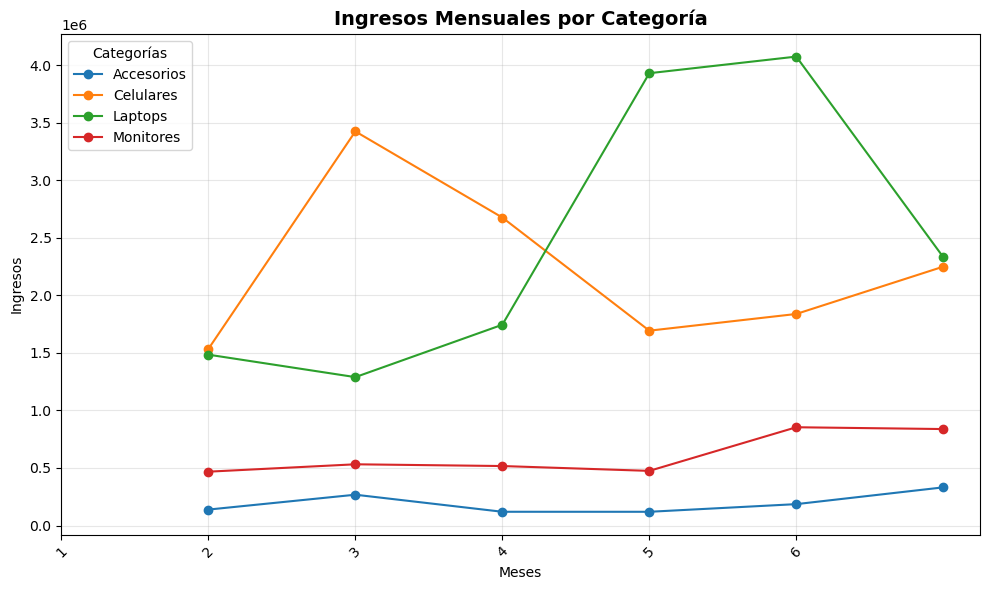

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

categorias = ventas_mensuales['categoria'].unique()
# Obtenemos los meses únicos para las etiquetas
meses = ventas_mensuales['mes'].unique()

for i in categorias:
    data = ventas_mensuales[ventas_mensuales['categoria'] == i]
    
    ax.plot(
        data['mes'],
        data['ingresos'],
        marker='o',       
        label=i         
    )

ax.set_title('Ingresos Mensuales por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Meses')
ax.set_ylabel('Ingresos')
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses, rotation=45)

ax.legend(title='Categorías')
ax.grid(True, alpha=0.3) 

plt.tight_layout()
plt.show()

## ¿Qué categoría presenta la mayor tasa de crecimiento mensual?

### laptops

## ¿Por qué se utiliza ax.set_xticks() junto con ax.set_xticklabels()?

### si usas ax.set_xticks() los valores serian simplemente las cordenadas y si solo usas ax.set_xticklabels(): Matplotlib pondra las marcas que él decidió poner automáticamente

## ¿Qué ventaja aporta el parámetro alpha en ax.grid()? Pruebe con alpha=1.0 y compare.

### Permite que la cuadrícula sirva de guía visual para leer los valores de manera mas profesional, alpha 1.0 se ve mas marcado

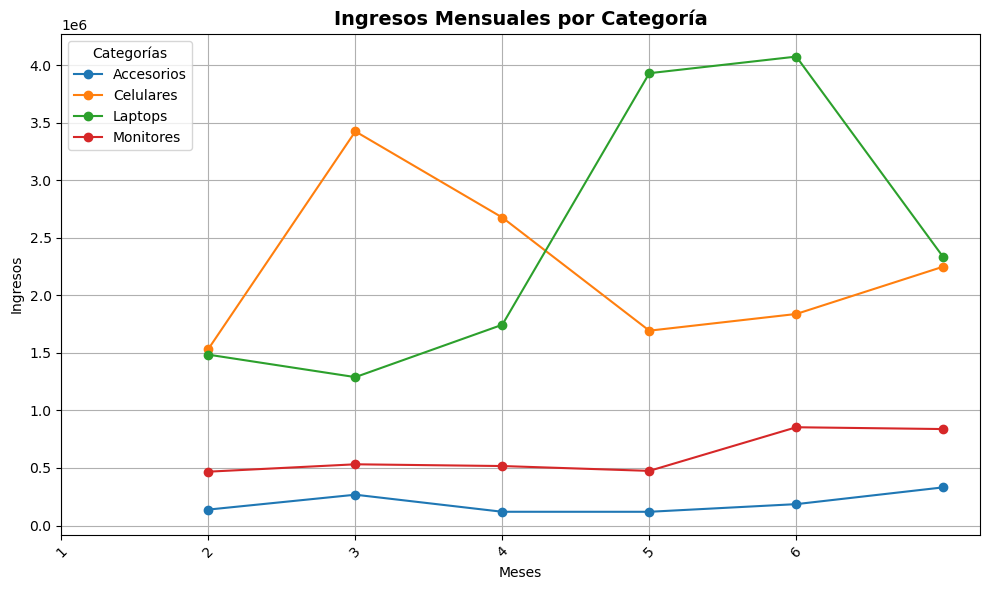

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

categorias = ventas_mensuales['categoria'].unique()
# Obtenemos los meses únicos para las etiquetas
meses = ventas_mensuales['mes'].unique()

for i in categorias:
    data = ventas_mensuales[ventas_mensuales['categoria'] == i]
    
    ax.plot(
        data['mes'],
        data['ingresos'],
        marker='o',       
        label=i         
    )

ax.set_title('Ingresos Mensuales por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Meses')
ax.set_ylabel('Ingresos')
ax.set_xticks(range(len(meses)))
ax.set_xticklabels(meses, rotation=45)

ax.legend(title='Categorías')
ax.grid(True, alpha=1) 

plt.tight_layout()
plt.show()

# Actividad 2 Gráfico de barras horizontal

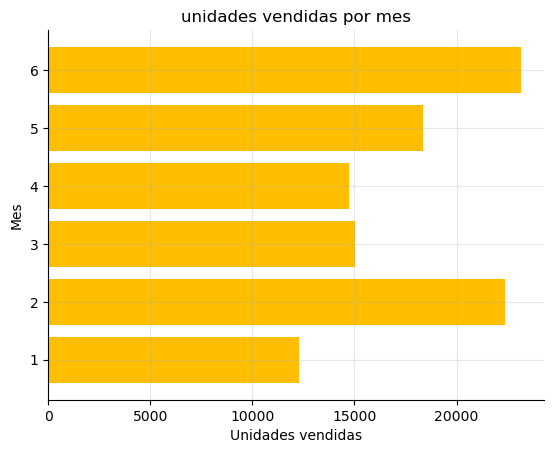

In [10]:
unidades_mes = df.groupby('mes')['unidades'].sum().reset_index()
colores = ['#FFBF00' if x > 1400 else '#540212' for x in unidades_mes['unidades']]
fig, ax = plt.subplots()

ax.barh(
    unidades_mes['mes'],
    unidades_mes['unidades'],
    color=colores
)

ax.set_title('unidades vendidas por mes')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('Mes')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(alpha=0.3)

#### ax.bar() genera barras verticales, donde las categorías se ubican en el eje X y los valores en el eje Y. En cambio, ax.barh() genera barras horizontales

#### Se eliminan los bordes superior y derecho para reducir el ruido visual y centrar la atención en los datos

# Actividad 3

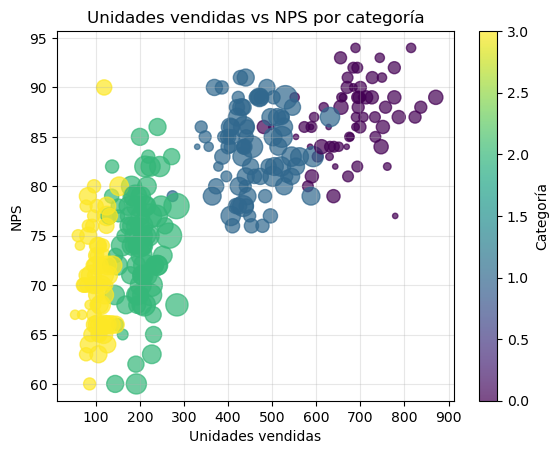

In [18]:
df['cat_num'] = df['categoria'].astype('category').cat.codes
fig, ax = plt.subplots()

scatter = ax.scatter(
    df['unidades'],          # X
    df['nps'],               # Y
    c=df['cat_num'],         # color por categoría
    s=df['devueltos'] * 15,  # tamaño
    cmap='viridis',          # colormap
    alpha=0.7
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Categoría')

ax.set_title('Unidades vendidas vs NPS por categoría')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('NPS')

ax.grid(alpha=0.3)

#### Se observa una relación positiva moderada entre el volumen de ventas y el NPS

#### El parámetro s en el gráfico de dispersión controla el tamaño de los puntos en unidades de área

#### La posición en el eje X representa el volumen de ventas (unidades vendidas).
#### La posición en el eje Y representa el nivel de satisfacción del cliente (NPS).
#### El color indica la categoría del producto, permitiendo diferenciar grupos dentro del mismo gráfico.
#### El tamaño de los puntos representa la cantidad de devoluciones

# Actividad 4

In [20]:
ingresos_cat = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_cat = df.groupby('categoria')['nps'].mean()
dev_cat = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')

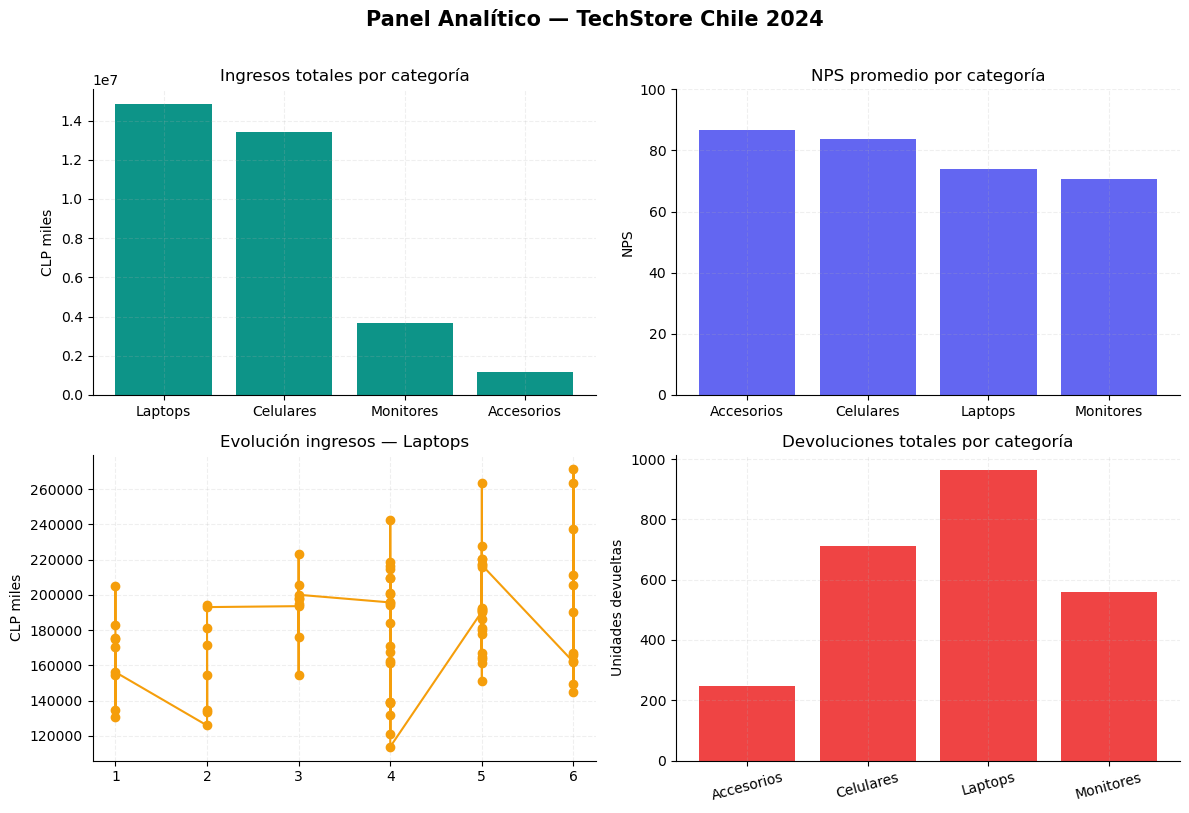

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

fig.suptitle('Panel Analítico — TechStore Chile 2024', fontsize=15, fontweight='bold', y=1.01)

# [0,0] Ingresos totales por categoría
axes[0,0].bar(ingresos_cat.index, ingresos_cat.values, color='#0D9488')
axes[0,0].set_title('Ingresos totales por categoría')
axes[0,0].set_ylabel('CLP miles')

# [0,1] NPS promedio por categoría
axes[0,1].bar(nps_cat.index, nps_cat.values, color='#6366F1')
axes[0,1].set_title('NPS promedio por categoría')
axes[0,1].set_ylabel('NPS')
axes[0,1].set_ylim(0, 100)

# [1,0] Evolución ingresos — Laptops
axes[1,0].plot(laptops['mes'], laptops['ingresos'], marker='o', color='#F59E0B')
axes[1,0].set_title('Evolución ingresos — Laptops')
axes[1,0].set_xticks(range(1, 7))
axes[1,0].set_ylabel('CLP miles')

# [1,1] Devoluciones por categoría
axes[1,1].bar(dev_cat.index, dev_cat.values, color='#EF4444')
axes[1,1].set_title('Devoluciones totales por categoría')
axes[1,1].set_ylabel('Unidades devueltas')
axes[1,1].tick_params(axis='x', rotation=15)

# Estilo general
for ax in axes.flat:
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### ¿Qué conclusión integrada puede extraer del panel observando los cuatro gráficos en conjunto?

#### que las categorías con mayores ingresos no necesariamente presentan los niveles más altos de satisfacción, el volumen de ventas no está directamente relacionado con la experiencia del cliente

### ¿Por qué se usa fig.suptitle() en lugar de ax.set_title() para el título global? ¿Cuál es la diferencia?

#### fig.suptitle() se utiliza para definir un título global que describe el contenido de toda la figura

### ¿Qué hace axes.flat en el bucle for al final? ¿Cómo simplifica el código?

#### axes.flat convierte la matriz de subgráficos en un iterable unidimensional, simplifica el código al evitar el uso de bucles anidados y facilita aplicar configuraciones comunes 

# Actividad 5

### ¿Qué ventaja aporta el ColumnDataSource frente a pasar listas directamente a p.vbar()?

#### que actúa como una fuente de datos compartida y reactiva

### ¿Cómo se define la cadena @mes_label en el tooltip? ¿Qué relación tiene con las claves del diccionario en ColumnDataSource?

#### @mes_label hace referencia a una columna del ColumnDataSource